A script used for temporal check for LOO validation

In [25]:
import numpy as np
import xarray as xr

# True data ALL
path = '/Users/bo20541/Library/CloudStorage/OneDrive-UniversityofBristol/TONIC-Oligocene/paleo-emu/examples/training_data/'
modhighice_all_Y=path+'training_data_highmodice_temp_formatted.nc'

ds = xr.open_dataset(modhighice_all_Y)
Y_true = ds['var'].values  # assuming 'var' is the variable name in the netCDF file  
latitudes = ds['lat'].values
longitudes = ds['lon'].values
lat_weights = np.cos(np.deg2rad(latitudes))
lat_weights /= lat_weights.mean()
weights_2d = np.tile(lat_weights[:, np.newaxis], (1, len(longitudes)))
def weighted_rmse(y_true, y_pred, weights):
    """Calculate the weighted RMSE between true and predicted values."""
    mse = np.average((y_true - y_pred) ** 2, weights=weights)
    return np.sqrt(mse)
def unweighted_rmse(y_true, y_pred):
    """Calculate the unweighted RMSE between true and predicted values."""
    mse = np.mean((y_true - y_pred) ** 2)
    return np.sqrt(mse)

In [26]:
# Load predictions and calculate RMSE for each case
Y_preds = []
rmses = []

for i in range(0,122):
    # Load prediction data
    Y_pred = xr.open_dataset(f'prediction_data/{i}case_LOO_emulation_modhighice_alltrain_predictions.nc')['temperature'].values
    Y_pred = np.squeeze(Y_pred)
    Y_preds.append(Y_pred)
    
    # Calculate weighted RMSE
    rmse = weighted_rmse(Y_true[i, :, :], Y_pred, weights_2d)
    rmses.append(rmse)
# save RMSEs as res file
rmse = np.array(rmses)
np.savetxt('LOO_RMSE_modhighice_alltrain.res', rmse)


In [27]:
# print("old rmse are RMSE for cases are: 0.18148759485184296, 0.13722311336015486, 0.12181980876116005, 0.15586159448569947, 0.14278639458967185")
print(f"RMSE for cases are: {', '.join(map(str, rmses))}")

RMSE for cases are: 0.2531283583442424, 0.21662277126551166, 0.2868118634534696, 0.3577206192599718, 0.2786448802071977, 0.2774262899263957, 0.21515701049635444, 0.2017199890154188, 0.30273938205500356, 0.1635473151979173, 0.25830345777774805, 0.15177429983017948, 0.2649619651386084, 0.2795375277937034, 0.2501573681901722, 0.4891544641876366, 0.2203682675721804, 0.2940529243060636, 0.276338315218059, 0.2778120231264341, 0.2595078706179596, 0.28547285318309384, 0.28978039543421585, 0.2525881698179005, 0.19257848896730465, 0.3282539741807797, 0.2610960576996826, 0.49555105767435703, 0.22554808385147754, 0.22827097244727118, 0.22189183674163732, 0.36944741186107516, 0.2812438221344412, 0.2868029283356275, 0.32727469440405976, 0.20569764412238095, 0.3195341026431815, 0.23979665777461356, 0.31836979676311067, 0.25904559479465195, 0.2802244777327777, 0.2858421071264733, 0.4605537207861551, 0.26276316018394663, 0.33573739374177297, 0.37123837926642633, 0.1989933267715923, 0.2684810277211114, 

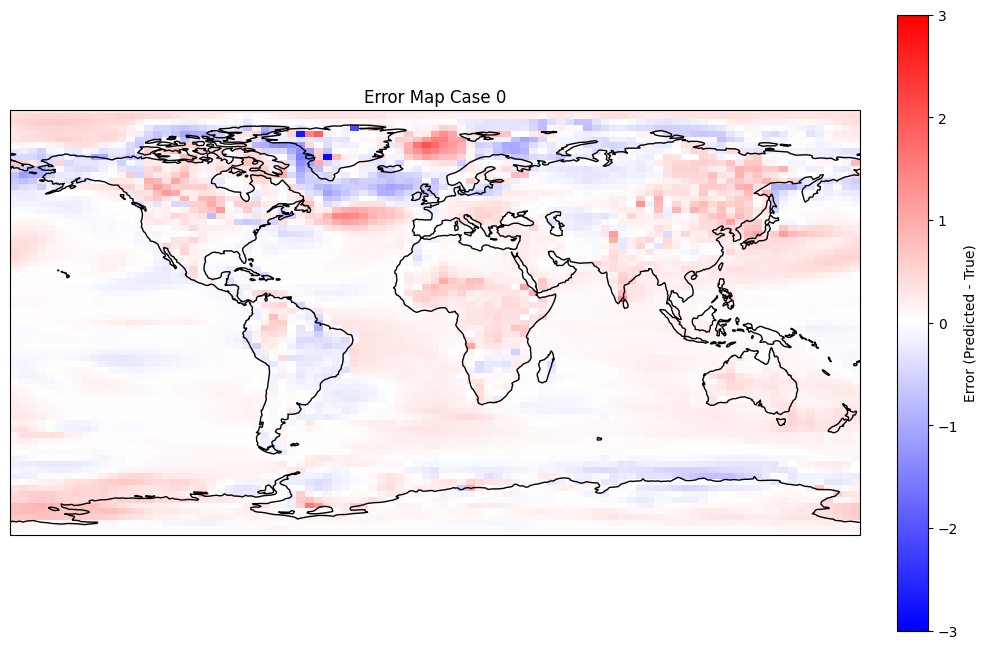

In [28]:
# plot maps of errors
import matplotlib.pyplot as plt
i = 0  # Change this to 0, 1, 2, 3, or 4 to plot different cases
error = Y_preds[i] - Y_true[i, :, :]
error = error[::-1, :]  # flip latitudes for plotting

import cartopy.crs as ccrs
fig, ax = plt.subplots(figsize=(12, 8), subplot_kw={'projection': ccrs.PlateCarree()})
vmin = -3
vmax = 3

im = ax.pcolormesh(longitudes, latitudes, error, cmap='bwr', vmin=vmin, vmax=vmax, transform=ccrs.PlateCarree())
ax.coastlines()
ax.set_title(f'Error Map Case {i}')
ax.set_xticks([])
ax.set_yticks([])

fig.colorbar(im, ax=ax, orientation='vertical', fraction=0.046, pad=0.04, label='Error (Predicted - True)')
plt.show()
